## ANALISIS DE VIGAS DE CONCRETO REFORZADO DOBLEMENTE REFORZADAS
## Diseñado por Andres David Villaquiran Bueno - Ing. civil 2026-1

In [1]:
# librerias
%reset -f

from numpy import array,around
from math import sqrt
from sympy import symbols, solve, Eq
from scipy.optimize import fsolve, minimize
import matplotlib.pyplot as plt


In [2]:
# Base datos refuerzo  
#           [calibre acero] , [diametro mm], [area mm2]
lista_refuerzo = array([[0, 0, 0],
                        [1, 0, 0],
                        [2, 6.4, 32],
                        [3, 9.5, 71],
                        [4, 12.7, 129],
                        [5, 15.9, 199] ,
                        [6, 19.1, 284],
                        [7, 22.2, 387],
                        [8, 25.4, 510],
                        [9, 28.7, 645],
                        [10, 32.3, 819],
                        [11, 35.8, 1006],
                        [12, 38.1, 1134],
                        [13, 41.3, 1335],
                        [14, 43, 1452],
                        [18, 57.3, 2581]])

GEOMETRIA Y MATERIAL

In [3]:
# prop. resistencia - Definimos las propiedades del concreto y el acero
fc = 21 #[MPa]
euc = 0.003
fy = 420 #[MPa]
Es = 2e5 #[MPa]
ey = fy/Es 
# Geometria - Definimos la geometria de la viga
b = 0.35 #[m]
h = 0.45 #[m]
r = 0.04 #[m]

DATOS DEL REFUERZO A TRACCION Y COMPRESION

In [4]:
# Refuerzo 
# Calibre del refuerzo longitudinal y del estribo
ref_long_t = 6 # N°
ref_long_c = 6 #N°
estribos = 3 # N° - Si no hay colocar 0

# Definimos el tipo de estribo y la cantidad de barras del refuerzo longitudinal
tipo_estribo = 1    # 1 - estribo rectangular, 2 - estribo espiral
num_barras_t = 5
num_barras_c = 2


FUNCION DE BLOQUE DE COMPRESIONES EN TERMINOS DE C

In [5]:
def area_compresion (c,B1,b):
    Ac = B1*c*0.35
    return Ac


CALCULOS PRIMERA PARTE - Acero minimo , altura efectiva, b1

In [6]:
# Propiedades refuerzo a traccion
dbt =lista_refuerzo[ref_long_t,1]/1000 #[m]  diametro de las barras de refuerzo
dbc =lista_refuerzo[ref_long_c,1]/1000 #[m]  diametro de las barras de refuerzo

area_barra_t = lista_refuerzo[ref_long_t,2]/1e6 #[m2]  Area de las barras de refuerzo
area_barra_c = lista_refuerzo[ref_long_c,2]/1e6 #[m2]  Area de las barras de refuerzo
de = lista_refuerzo[estribos,1]/1000 #[m] diametro de los estribos

# Altura efectiva a compresion y traccion
d = h - r - de- dbt/2  # Calculo altura efectiva de la viga
d = 0.3905
#dp = r + de + dbc/2  # Distancia acero compresion
dp = r+0.01+dbc/2
print(f"d=  {round(d,5)}   d' =  {round(dp,5)} ")

#As = num_barras_t*area_barra_t #[m2] # Area de acero de la viga
As = 0.0008 
#Asp = num_barras_c*area_barra_c #[m2] # Area de acero de la viga
Asp = 0.001136

print(f"As=  {As}     As' =  {Asp} ")

# VERIFICO ACERO MINIMO
As_m1 =0.25*sqrt(fc)*b*d/fy 
As_m2 = 1.4*b*d/fy
As_min = max(As_m1, As_m2) # Acero minimo requerido
# ¿Cumple acero minimo?
if As < As_min:
    print("NO cumple acero minimo")
else: 
    print("CUMPLE acero minimo requerido")

# Calculamos B1 segun f'c
if fc >= 17:
    if fc < 28:
        B1 = 0.85
    elif fc < 56:
        B1 = 0.85-0.05*(fc-28)/7
    else:
        B1 = 0.65
else: 
    print("Defina un fc valido")        
print("B1 = ", B1)

d=  0.3905   d' =  0.05955 
As=  0.0008     As' =  0.001136 
CUMPLE acero minimo requerido
B1 =  0.85


CONDICION BALANCEADA

In [7]:
#CONDICION BALANCEADA
cb = euc*d/(euc+ey)  # Eje neutro balanceado
espb = euc*(cb-dp)/cb # def acero comp en balanceada
if espb >= ey: # defino esfuerzo de As' en balanceada
    fspb = fy
else:
    fspb = Es*espb

Acb = area_compresion(cb, B1,b)
Asb = (0.85*fc*(Acb-Asp)+Asp*fspb)/fy  # Area acero balanceado

print(f"Asb = {round(Asb,6)} [m2]")
print(f"cb = {round(cb,4)} [m] ")

# Definimos el tipo de viga segun el acero de refuerzo
#c = symbols('c')
if As < Asb:
    print("VIGA SUB_REFORZADA")
    tipo = "sub"
    #fs = fy
else:
    print("VIGA SOBRE_REFORZADA")
    tipo = "sobre"    
print(f"Acb = {round(Acb,6)} [m2]")


Asb = 0.003992 [m2]
cb = 0.2297 [m] 
VIGA SUB_REFORZADA
Acb = 0.068337 [m2]


CALCULO DE C SEGUN TIPO DE VIGA

In [8]:


def eje_neutro(dp,euc,d,Es,fy,fc,B1,Asp, As,tipo,sup): 
    def Eq1(c):
        cv =c[0]
        if tipo == "sub":
            fs = fy
        else:
            fs = Es*euc*(d-cv)/cv
        if sup == "fluye":
            fsp = fy
        elif sup == "no_fluye":
            fsp = Es*euc*(cv-dp)/cv
        # Planteamos ecuación
        return (0.85*fc*(area_compresion(cv,B1,b)-Asp) + Asp*fsp - As*fs)**2
    # Solucion del sistema de ecuaciones
    restricciones = [ 
                {'type': 'ineq', 'fun': lambda c: c[0] + d },
                {'type': 'ineq', 'fun': lambda c: c[0] - 0.0 },
                {'type': 'ineq', 'fun': lambda c: c[0] - 0.005 },
    ]
    resultado = minimize(Eq1, x0=[ 0.06], constraints=restricciones)
    c = resultado.x

    return c
 

Iteración para la solución de c 
1. As'  fluye
2. As' No Fluye

In [9]:
#SUPONEMOS QUE As' fluye y hacemos el calculo
# As' fluye
sup = "fluye"
#-----------------------------------------------------------------
# Solucion del sistema de ecuaciones
resultado = eje_neutro(dp,euc,d,Es,fy,fc,B1,Asp, As, tipo,sup)
c = float(resultado[0])
#  ---------------------------------------------------------------

# Verificamos deformación segun suposición
esp = euc*(c-dp)/c

if esp >= ey :
    print("FLUYE acero compresion")
    fsp = fy
    print("c = ", c)
    print("esp = ", esp)
else:
    sup = "no_fluye"  
    # ------------------------------------------------------------
    # Solucion del sistema de ecuaciones 
    resultado = eje_neutro(dp,euc,d,Es,fy,fc,B1,Asp, As, tipo,sup)
    c = float(resultado[0])
    #-------------------------------------------------------------
    esp = euc*(c-dp)/c
    fsp = Es*esp
    print("NO FLUYE acero compresion ")
    print("esp = ", esp)
    print("c = ", c)
    
# Calculamos altura de el cubo de whitney
a = B1*c
print("a = ", a)


es = euc*(d-c)/c
dyp = c - c*ey/euc
print(f"es =  {round(es,6)}   fsp =  {round(fsp,4)}    dy' = {round(dyp,4)}"  )

if es > (ey+euc):
    condicion = "traccion"
    print("Viga controlada por ", condicion)
elif es < (ey+euc) and es > ey:
    condicion= "transicion"
    print("Viga controlada por ", condicion)
else:
    condicion = "compresion"
    print("Viga controlada por ", condicion)

if As < Asb:
    tipo = "sub"
    fs = fy
else:
    tipo = "sobre"
    fs = Es*euc*(d-c)/c
print("fs = ", round(fs,4), "[MPa]")     
Ac = area_compresion(c,B1,b)
print("Ac = ", round(Ac,6), "[m2]")

NO FLUYE acero compresion 
esp =  0.00011981467434451874
c =  0.062027258596403796
a =  0.05272316980694323
es =  0.015887   fsp =  23.9629    dy' = 0.0186
Viga controlada por  traccion
fs =  420 [MPa]
Ac =  0.018453 [m2]


In [10]:
print(resultado)

[0.06202726]


CALCULOS DE PARAMETROS FINALES Mn , phiMn , curvatura, a

In [11]:
# Calculamos el curvatura 
curvatura = euc/c
print("curvatura = ", curvatura)    


# CALCULAMOS EL ESFUERZO EN EL ACERO Y EL MOMENTO NOMINAL RESISTENTE DE LA VIGA
# PARA CADA TIPO DE VIGA Y DE ESTRIBO DEFINIMOS EL FACTOR DE REDUCCION DE RESISTENCIA PHI

# VIGA SOBREFORZADA

if tipo == "sobre":
    if tipo_estribo == 1:
        phi = 0.65
    elif tipo_estribo == 2:
        phi = 0.75      
    else:
        print("Defina un tipo de estribo valido")   

## VIGA SUB REFORZADA   
elif tipo == "sub":
    fs = fy 
    if condicion == "traccion":
        phi = 0.9
    elif condicion == "transicion":
        if tipo_estribo == 1:
            phi = 0.65 + 0.25*(es-ey)/euc
        elif tipo_estribo == 2:
            phi = 0.75 + 0.15*(es-ey)/euc
        else:
            print("Defina un tipo de estribo valido") 


ycentroidal = a/2
Mn = 0.85*fc*1000*(area_compresion(c,B1,b)-Asp)*(d-ycentroidal) + Asp*fsp*1000*(d-dp) #[kN-m]
phi_Mn = phi*Mn
print(f"fs = {round(fs,3)} [MPa]")
print("phi = ", round(phi,3))
print(f"Mn = {round(Mn,4)} [kN-m]")
print(f"phi_Mn = {round(phi_Mn,4)} [kN-m]")       

curvatura =  0.04836583250471001
fs = 420 [MPa]
phi =  0.9
Mn = 121.5681 [kN-m]
phi_Mn = 109.4113 [kN-m]


# RESUMEN DE RESULTADOS

In [12]:

#IMPRESION DE DATOS 
print("PROPIEDADES VIGA")
print(f" Altura efectiva (d)= {d} [m]             Distancia comp (d') = {dp} [m]   ")
print(f" Acero traccion (As)= {round(As,7)} [m2]          Acero compresion (As')= {round(Asp,7)} [m2]   ")
print(" ")
print("CONDICIÓN BALANCEADA")
print(f" Eje neutro balc (cb)= {round(cb,5)} [m]          Acero balanceado = {round(Asb,6)} [m2]   ")
print(" ")
print("RESULTADOS VIGA")
print(f" Tipo de viga = {tipo}                             Falla = {condicion}     Acero compresion = {sup} ")
print(f" Eje neutro(c)= {round(c,5)} [m]        B1 = {B1}     Altura bloque whithney (a) = {round(a,5)} [m]   ")
print(f" Def acero tracc (es) = {round(es,6)} [m/m]            Def acero compr (es') = {round(esp,6)} [m/m]      dy' = {round(dyp,4)} [m]")
print(f" Esfuerso tracc As (fs) = {round(fs,3)} [Mpa]           Esfuerso comp As' (fs') = {round(fsp,3)} [Mpa]      curvatura (k) = {round(curvatura,4)} [1/m]")
print(" ")
print(f" Momentos nominal (Mn) = {round(Mn,3)} [kN-m]    phi = {round(phi,4)}      Momentos nominal reducido (Mn) = {round(phi_Mn,3)} [kN-m] ")



PROPIEDADES VIGA
 Altura efectiva (d)= 0.3905 [m]             Distancia comp (d') = 0.059550000000000006 [m]   
 Acero traccion (As)= 0.0008 [m2]          Acero compresion (As')= 0.001136 [m2]   
 
CONDICIÓN BALANCEADA
 Eje neutro balc (cb)= 0.22971 [m]          Acero balanceado = 0.003992 [m2]   
 
RESULTADOS VIGA
 Tipo de viga = sub                             Falla = traccion     Acero compresion = no_fluye 
 Eje neutro(c)= 0.06203 [m]        B1 = 0.85     Altura bloque whithney (a) = 0.05272 [m]   
 Def acero tracc (es) = 0.015887 [m/m]            Def acero compr (es') = 0.00012 [m/m]      dy' = 0.0186 [m]
 Esfuerso tracc As (fs) = 420 [Mpa]           Esfuerso comp As' (fs') = 23.963 [Mpa]      curvatura (k) = 0.0484 [1/m]
 
 Momentos nominal (Mn) = 121.568 [kN-m]    phi = 0.9      Momentos nominal reducido (Mn) = 109.411 [kN-m] 


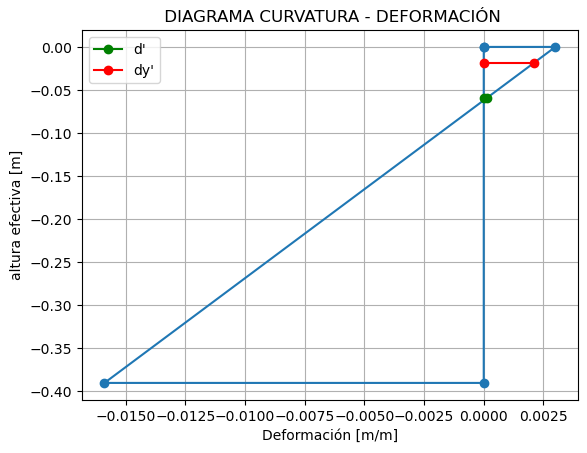

In [ ]:
# IMPRESION DEL DIAGRAMA CURVATURA DEFORMACION
coord = array([
    [  0 ,  0 ],
    [ euc , 0 ],
    [ -es , -d],
    [  0 ,  -d],
    [   0 , 0 ],
])

coord2 = array([
    [0, -dp],
    [float(esp), -dp],
])
fluy_comp = array([ 
            [0 , - dyp],
            [ey, -dyp],
])

fig , ax = plt.subplots()
ax.plot(coord[:,0], coord[:,1], marker = "o") # Dibuja los puntos
ax.plot(coord2[:,0], coord2[:,1], marker = "o", color = "green", label = "d'")
ax.plot(fluy_comp[:,0], fluy_comp[:,1], marker = "o", color = "red", label = "dy'")
ax.legend()
plt.title(label = " DIAGRAMA CURVATURA - DEFORMACIÓN")
plt.xlabel("Deformación [m/m]") # Titulo eje x
plt.ylabel("altura efectiva [m]") # Titulo eje y

plt.grid(True) # Dibuje la malla

plt.show()
#ax.set_aspect("equal") # Ejes misma escala
